<a href="https://colab.research.google.com/github/Amarnath718/object-detection_opencv/blob/main/LightGlue_FPGA_Profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Check whether GPU is available
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
#Download LightGlue
!git clone https://github.com/cvg/LightGlue.git

Cloning into 'LightGlue'...
remote: Enumerating objects: 419, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 419 (delta 2), reused 0 (delta 0), pack-reused 413 (from 2)
Receiving objects: 100% (419/419), 13.71 MiB | 17.91 MiB/s, done.
Resolving deltas: 100% (249/249), done.


In [3]:
%cd LightGlue

/content/LightGlue


In [4]:
#Installing all packages
!pip install -e .

Obtaining file:///content/LightGlue
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 119.5 MB/s eta 0:00:00
  Building editable for lightglue (pyproject.toml) ... done
  Created wheel for lightglue: filename=lightglue-0.0-0.editable-py3-none-any.whl size=14947 sha256=081d2abf1212d3a39dfab5503ea223297a4fee0fceda5c0889c8c85addd65ccc
  Stored in directory: /tmp/pip-ephem-wheel-cache-l_zaoljk/wheels/25/5f/13/5e6e3a84d62c0c7c3789dce4079a5f18ef3319edd4074ee84e
Successfully built lightglue


In [5]:
#Import everything
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

from lightglue import LightGlue, SuperPoint
from lightglue.utils import load_image

In [6]:
#Load the feature extractor and LightGlue
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

extractor = SuperPoint(max_num_keypoints=1024).eval().to(device)
matcher = LightGlue(features="superpoint").eval().to(device)

Using device: cuda
Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_v1.pth" to /root/.cache/torch/hub/checkpoints/superpoint_v1.pth


100%|██████████| 4.96M/4.96M [00:00<00:00, 92.6MB/s]


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_lightglue.pth" to /root/.cache/torch/hub/checkpoints/superpoint_lightglue_v0-1_arxiv.pth


100%|██████████| 45.3M/45.3M [00:00<00:00, 144MB/s]


In [7]:
#Get two test images
!ls assets

architecture.svg   benchmark.png  DSC_0411.JPG	 sacre_coeur1.jpg  teaser.svg
benchmark_cpu.png  DSC_0410.JPG   easy_hard.jpg  sacre_coeur2.jpg


In [8]:
#Load the images
image0 = load_image("assets/sacre_coeur1.jpg").to(device)
image1 = load_image("assets/sacre_coeur2.jpg").to(device)

print("Image 0 shape:", image0.shape)
print("Image 1 shape:", image1.shape)

Image 0 shape: torch.Size([3, 731, 1024])
Image 1 shape: torch.Size([3, 1024, 768])


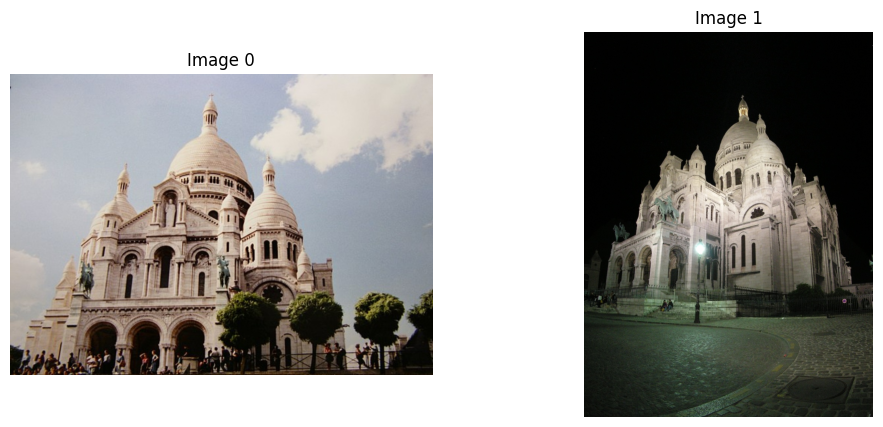

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image0.permute(1, 2, 0).cpu())
axes[0].set_title("Image 0")
axes[0].axis("off")

axes[1].imshow(image1.permute(1, 2, 0).cpu())
axes[1].set_title("Image 1")
axes[1].axis("off")

plt.show()

In [10]:
#Extract Features
with torch.inference_mode():
    feats0 = extractor.extract(image0)
    feats1 = extractor.extract(image1)

print("Image 0 keypoints:", feats0["keypoints"].shape)
print("Image 1 keypoints:", feats1["keypoints"].shape)

print("Image 0 descriptors:", feats0["descriptors"].shape)
print("Image 1 descriptors:", feats1["descriptors"].shape)

Image 0 keypoints: torch.Size([1, 1024, 2])
Image 1 keypoints: torch.Size([1, 1024, 2])
Image 0 descriptors: torch.Size([1, 1024, 256])
Image 1 descriptors: torch.Size([1, 1024, 256])


In [11]:
#Run lightglue
with torch.inference_mode():
    matches01 = matcher({"image0": feats0, "image1": feats1})

print(matches01.keys())

dict_keys(['matches0', 'matches1', 'matching_scores0', 'matching_scores1', 'stop', 'matches', 'scores', 'prune0', 'prune1'])


In [12]:
# Inspect matches
matches = matches01["matches"]

print("Type of matches:", type(matches))
print("Number of matched features:", len(matches))

Type of matches: <class 'list'>
Number of matched features: 1


In [13]:
print("Number of elements:", len(matches))

if len(matches) > 0:
    print("First element:", matches[0])
    print("Type of first element:", type(matches[0]))

Number of elements: 1
First element: tensor([[   3,  256],
        [   5,   58],
        [   8,   62],
        [  13,   96],
        [  18,   68],
        [  22,  183],
        [  24,   98],
        [  26,  862],
        [  41,  602],
        [  43,  536],
        [  47,    5],
        [  49,  177],
        [  60,   42],
        [  69,  741],
        [  71,   88],
        [  73,  180],
        [  76,   30],
        [  87,  755],
        [  96,   17],
        [ 101,  530],
        [ 105,  863],
        [ 106,  415],
        [ 109,  575],
        [ 116,  154],
        [ 122,  509],
        [ 148,  110],
        [ 150,  516],
        [ 151,  230],
        [ 153,  331],
        [ 154,    4],
        [ 158,  784],
        [ 160,  757],
        [ 169,  593],
        [ 173,   31],
        [ 178,  672],
        [ 180,  217],
        [ 183,  444],
        [ 186,  742],
        [ 187,   83],
        [ 192,  325],
        [ 199,  505],
        [ 200,  646],
        [ 221,  838],
        [ 223,   

In [14]:
for i, match in enumerate(matches[:10]):
    print(i, match)

0 tensor([[   3,  256],
        [   5,   58],
        [   8,   62],
        [  13,   96],
        [  18,   68],
        [  22,  183],
        [  24,   98],
        [  26,  862],
        [  41,  602],
        [  43,  536],
        [  47,    5],
        [  49,  177],
        [  60,   42],
        [  69,  741],
        [  71,   88],
        [  73,  180],
        [  76,   30],
        [  87,  755],
        [  96,   17],
        [ 101,  530],
        [ 105,  863],
        [ 106,  415],
        [ 109,  575],
        [ 116,  154],
        [ 122,  509],
        [ 148,  110],
        [ 150,  516],
        [ 151,  230],
        [ 153,  331],
        [ 154,    4],
        [ 158,  784],
        [ 160,  757],
        [ 169,  593],
        [ 173,   31],
        [ 178,  672],
        [ 180,  217],
        [ 183,  444],
        [ 186,  742],
        [ 187,   83],
        [ 192,  325],
        [ 199,  505],
        [ 200,  646],
        [ 221,  838],
        [ 223,   92],
        [ 229,  206],
        

In [15]:
# Baselining Lightglue timing
def synchronize():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

In [16]:
# Warm-up
with torch.inference_mode():
    for _ in range(10):
        matcher({"image0": feats0, "image1": feats1})

synchronize()

times = []

for _ in range(50):
    synchronize()

    start = time.perf_counter()

    with torch.inference_mode():
        matcher({"image0": feats0, "image1": feats1})

    synchronize()

    end = time.perf_counter()

    times.append((end - start) * 1000)

print("Average LightGlue time:",
      np.mean(times), "ms")

print("Minimum LightGlue time:",
      np.min(times), "ms")

print("Maximum LightGlue time:",
      np.max(times), "ms")

Average LightGlue time: 36.41706812000848 ms
Minimum LightGlue time: 19.770511000160695 ms
Maximum LightGlue time: 109.95482699991044 ms


In [17]:
#Profile the entire LightGlue model
import torch.profiler

with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA
    ],
    record_shapes=True,
    profile_memory=True
) as prof:

    with torch.inference_mode():
        matcher({"image0": feats0, "image1": feats1})

/usr/local/lib/python3.13/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


In [18]:
print(
    prof.key_averages().table(
        sort_by="cuda_time_total",
        row_limit=30
    )
)

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::linear         3.05%       1.189ms        24.84%       9.671ms      66.239us       0.000us         0.00%       8.151ms      55.828us           0 B           0 B     184.31 MB           0 

In [19]:
print(matcher)

LightGlue(
  (input_proj): Identity()
  (posenc): LearnableFourierPositionalEncoding(
    (Wr): Linear(in_features=2, out_features=32, bias=False)
  )
  (transformers): ModuleList(
    (0-8): 9 x TransformerLayer(
      (self_attn): SelfBlock(
        (Wqkv): Linear(in_features=256, out_features=768, bias=True)
        (inner_attn): Attention()
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
        (ffn): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (2): GELU(approximate='none')
          (3): Linear(in_features=512, out_features=256, bias=True)
        )
      )
      (cross_attn): CrossBlock(
        (to_qk): Linear(in_features=256, out_features=256, bias=True)
        (to_v): Linear(in_features=256, out_features=256, bias=True)
        (to_out): Linear(in_features=256, out_features=256, bias=True)
        (ffn): Sequential(
          (0): Linear

In [20]:
print("Number of LightGlue layers:", len(matcher.transformers))

Number of LightGlue layers: 9


In [21]:
for i, layer in enumerate(matcher.transformers):
    print("\n========== Layer", i, "==========")
    print(layer)


========== Layer 0 ==========
TransformerLayer(
  (self_attn): SelfBlock(
    (Wqkv): Linear(in_features=256, out_features=768, bias=True)
    (inner_attn): Attention()
    (out_proj): Linear(in_features=256, out_features=256, bias=True)
    (ffn): Sequential(
      (0): Linear(in_features=512, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=512, out_features=256, bias=True)
    )
  )
  (cross_attn): CrossBlock(
    (to_qk): Linear(in_features=256, out_features=256, bias=True)
    (to_v): Linear(in_features=256, out_features=256, bias=True)
    (to_out): Linear(in_features=256, out_features=256, bias=True)
    (ffn): Sequential(
      (0): Linear(in_features=512, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=512, out_features=256, bias=True)
    )
    (flash): At

In [22]:
#PART 2
import torch
import time
from collections import defaultdict

# Store timings
timings = defaultdict(list)

# Original forward functions
original_forwards = {}

# Get all 9 Transformer layers
layers = matcher.transformers

print("Number of Transformer layers:", len(layers))

Number of Transformer layers: 9


In [23]:
def make_timed_forward(module, name):
    original_forward = module.forward

    def timed_forward(*args, **kwargs):

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        output = original_forward(*args, **kwargs)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end = time.perf_counter()

        timings[name].append((end - start) * 1000)

        return output

    return original_forward, timed_forward


# Install timing around each component
for i, layer in enumerate(layers):

    # Self-attention
    original_forwards[f"layer{i}_self"] = layer.self_attn.forward

    layer.self_attn.forward = make_timed_forward(
        layer.self_attn,
        f"layer{i}_self"
    )[1]

    # Cross-attention
    original_forwards[f"layer{i}_cross"] = layer.cross_attn.forward

    layer.cross_attn.forward = make_timed_forward(
        layer.cross_attn,
        f"layer{i}_cross"
    )[1]

print("Timing instrumentation installed.")

Timing instrumentation installed.


In [24]:
# Clear previous timings
timings.clear()

# Warm-up
with torch.no_grad():
    for _ in range(10):
        matcher({
            "image0": feats0,
            "image1": feats1
        })

# Actual measurements
with torch.no_grad():
    for _ in range(30):
        matcher({
            "image0": feats0,
            "image1": feats1
        })

print("Profiling completed.")

Profiling completed.


In [25]:
print("\n========== PER-LAYER TIMING ==========\n")

for i in range(len(layers)):

    self_times = timings[f"layer{i}_self"]
    cross_times = timings[f"layer{i}_cross"]

    print(f"Layer {i}:")

    if len(self_times) > 0:
        self_avg = sum(self_times) / len(self_times)
        print(f"  Self-Block  : {self_avg:.4f} ms")
    else:
        print("  Self-Block  : No data")

    if len(cross_times) > 0:
        cross_avg = sum(cross_times) / len(cross_times)
        print(f"  Cross-Block : {cross_avg:.4f} ms")
    else:
        print("  Cross-Block : No data")

    print()


========== PER-LAYER TIMING ==========

Layer 0:
  Self-Block  : 1.0584 ms
  Cross-Block : 1.2662 ms

Layer 1:
  Self-Block  : 0.9969 ms
  Cross-Block : 1.2687 ms

Layer 2:
  Self-Block  : 0.9761 ms
  Cross-Block : 1.2344 ms

Layer 3:
  Self-Block  : 0.9969 ms
  Cross-Block : 1.2619 ms

Layer 4:
  Self-Block  : 0.9827 ms
  Cross-Block : 1.2428 ms

Layer 5:
  Self-Block  : 0.9792 ms
  Cross-Block : 1.2310 ms

Layer 6:
  Self-Block  : 0.9824 ms
  Cross-Block : 1.3177 ms

Layer 7:
  Self-Block  : No data
  Cross-Block : No data

Layer 8:
  Self-Block  : No data
  Cross-Block : No data



In [26]:
# Inspect Layer 0 Cross-Block

cross_block = matcher.transformers[0].cross_attn

print(cross_block)

CrossBlock(
  (to_qk): Linear(in_features=256, out_features=256, bias=True)
  (to_v): Linear(in_features=256, out_features=256, bias=True)
  (to_out): Linear(in_features=256, out_features=256, bias=True)
  (ffn): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=512, out_features=256, bias=True)
  )
  (flash): Attention()
)


In [27]:
#Install timers inside cross block
import time
from collections import defaultdict

cross_timings = defaultdict(list)

# We will profile the components of every CrossBlock
for layer_idx, layer in enumerate(matcher.transformers):

    cross = layer.cross_attn

    # Save original functions
    cross._original_to_qk = cross.to_qk.forward
    cross._original_to_v = cross.to_v.forward
    cross._original_to_out = cross.to_out.forward
    cross._original_ffn = cross.ffn.forward
    cross._original_flash = cross.flash.forward

    # Function to create a timer
    def make_timer(original_forward, name):

        def timed_forward(*args, **kwargs):

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            start = time.perf_counter()

            output = original_forward(*args, **kwargs)

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            end = time.perf_counter()

            cross_timings[name].append(
                (end - start) * 1000
            )

            return output

        return timed_forward

    # Attach timers
    cross.to_qk.forward = make_timer(
        cross._original_to_qk,
        f"layer{layer_idx}_to_qk"
    )

    cross.to_v.forward = make_timer(
        cross._original_to_v,
        f"layer{layer_idx}_to_v"
    )

    cross.to_out.forward = make_timer(
        cross._original_to_out,
        f"layer{layer_idx}_to_out"
    )

    cross.ffn.forward = make_timer(
        cross._original_ffn,
        f"layer{layer_idx}_ffn"
    )

    cross.flash.forward = make_timer(
        cross._original_flash,
        f"layer{layer_idx}_attention"
    )

print("Cross-Block component timing installed.")

Cross-Block component timing installed.


In [28]:
cross_timings.clear()

# Warm-up
with torch.no_grad():
    for _ in range(10):
        matcher({
            "image0": feats0,
            "image1": feats1
        })

# Actual measurements
with torch.no_grad():
    for _ in range(30):
        matcher({
            "image0": feats0,
            "image1": feats1
        })

print("Stage 3 profiling completed.")

Stage 3 profiling completed.


In [29]:
# Display the result
print("\n========== CROSS-BLOCK COMPONENT TIMING ==========\n")

components = [
    "to_qk",
    "to_v",
    "attention",
    "to_out",
    "ffn"
]

for component in components:

    values = []

    for layer_idx in range(len(matcher.transformers)):

        key = f"layer{layer_idx}_{component}"

        if len(cross_timings[key]) > 0:
            values.extend(cross_timings[key])

    if len(values) > 0:
        average = sum(values) / len(values)
        print(f"{component:12s}: {average:.4f} ms")
    else:
        print(f"{component:12s}: No data")


========== CROSS-BLOCK COMPONENT TIMING ==========

to_qk       : 0.0897 ms
to_v        : 0.0830 ms
attention   : 0.2641 ms
to_out      : 0.0991 ms
ffn         : 0.2635 ms


In [30]:
feats0 = extractor.extract(image0)
feats1 = extractor.extract(image1)

matcher = LightGlue(features="superpoint").eval().cuda()

In [31]:
#First verify Cross-Attention structure
print(matcher.transformers[0].cross_attn)

CrossBlock(
  (to_qk): Linear(in_features=256, out_features=256, bias=True)
  (to_v): Linear(in_features=256, out_features=256, bias=True)
  (to_out): Linear(in_features=256, out_features=256, bias=True)
  (ffn): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=512, out_features=256, bias=True)
  )
  (flash): Attention()
)


In [32]:
#import
import torch
import time
import inspect
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [33]:
from lightglue import LightGlue, SuperPoint
from lightglue.utils import load_image

extractor = SuperPoint(max_num_keypoints=1024).eval().to(device)
matcher = LightGlue(features="superpoint").eval().to(device)

print("Extractor and matcher loaded")

Extractor and matcher loaded


In [34]:
image0 = load_image("/content/LightGlue/assets/sacre_coeur1.jpg")
image1 = load_image("/content/LightGlue/assets/sacre_coeur2.jpg")

print("Images loaded")

Images loaded


In [35]:
with torch.no_grad():
    feats0 = extractor.extract(image0.to(device))
    feats1 = extractor.extract(image1.to(device))

print("Features extracted")
print("Keypoints image 0:", feats0["keypoints"].shape)
print("Keypoints image 1:", feats1["keypoints"].shape)
print("Descriptor image 0:", feats0["descriptors"].shape)
print("Descriptor image 1:", feats1["descriptors"].shape)

Features extracted
Keypoints image 0: torch.Size([1, 1024, 2])
Keypoints image 1: torch.Size([1, 1024, 2])
Descriptor image 0: torch.Size([1, 1024, 256])
Descriptor image 1: torch.Size([1, 1024, 256])


In [36]:
cross_block = matcher.transformers[0].cross_attn

print(inspect.getsource(cross_block.forward))

    def forward(
        self, x0: torch.Tensor, x1: torch.Tensor, mask: Optional[torch.Tensor] = None
    ) -> List[torch.Tensor]:
        qk0, qk1 = self.map_(self.to_qk, x0, x1)
        v0, v1 = self.map_(self.to_v, x0, x1)
        qk0, qk1, v0, v1 = map(
            lambda t: t.unflatten(-1, (self.heads, -1)).transpose(1, 2),
            (qk0, qk1, v0, v1),
        )
        if self.flash is not None and qk0.device.type == "cuda":
            m0 = self.flash(qk0, qk1, v1, mask)
            m1 = self.flash(
                qk1, qk0, v0, mask.transpose(-1, -2) if mask is not None else None
            )
        else:
            qk0, qk1 = qk0 * self.scale**0.5, qk1 * self.scale**0.5
            sim = torch.einsum("bhid, bhjd -> bhij", qk0, qk1)
            if mask is not None:
                sim = sim.masked_fill(~mask, -float("inf"))
            attn01 = F.softmax(sim, dim=-1)
            attn10 = F.softmax(sim.transpose(-2, -1).contiguous(), dim=-1)
            m0 = torch.einsum(

In [37]:
# Profile the Flash Attention operation itself

cross_block = matcher.transformers[0].cross_attn

print("Flash Attention module:")
print(cross_block.flash)

print("\nFlash Attention source:")
print(inspect.getsource(cross_block.flash.forward))

Flash Attention module:
Attention()

Flash Attention source:
    def forward(self, q, k, v, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        if q.shape[-2] == 0 or k.shape[-2] == 0:
            return q.new_zeros((*q.shape[:-1], v.shape[-1]))
        if self.enable_flash and q.device.type == "cuda":
            # use torch 2.0 scaled_dot_product_attention with flash
            if self.has_sdp:
                args = [x.half().contiguous() for x in [q, k, v]]
                v = F.scaled_dot_product_attention(*args, attn_mask=mask).to(q.dtype)
                return v if mask is None else v.nan_to_num()
            else:
                assert mask is None
                q, k, v = [x.transpose(-2, -3).contiguous() for x in [q, k, v]]
                m = self.flash_(q.half(), torch.stack([k, v], 2).half())
                return m.transpose(-2, -3).to(q.dtype).clone()
        elif self.has_sdp:
            args = [x.contiguous() for x in [q, k, v]]
            v = F.scaled

In [38]:
import torch
import torch.nn.functional as F
import time

attention_timings = {
    "QK^T": [],
    "Softmax": [],
    "Attention x V": []
}

def profile_reference_attention(q, k, v, mask=None):

    # -------------------------
    # 1. Q × K^T
    # -------------------------
    torch.cuda.synchronize()
    start = time.perf_counter()

    scale = q.shape[-1] ** -0.5
    sim = torch.einsum(
        "...id,...jd->...ij",
        q,
        k
    ) * scale

    if mask is not None:
        sim = sim.masked_fill(~mask, -float("inf"))

    torch.cuda.synchronize()
    end = time.perf_counter()

    attention_timings["QK^T"].append(
        (end - start) * 1000
    )

    # -------------------------
    # 2. Softmax
    # -------------------------
    torch.cuda.synchronize()
    start = time.perf_counter()

    attn = F.softmax(sim, dim=-1)

    torch.cuda.synchronize()
    end = time.perf_counter()

    attention_timings["Softmax"].append(
        (end - start) * 1000
    )

    # -------------------------
    # 3. Attention × V
    # -------------------------
    torch.cuda.synchronize()
    start = time.perf_counter()

    output = torch.einsum(
        "...ij,...jd->...id",
        attn,
        v
    )

    torch.cuda.synchronize()
    end = time.perf_counter()

    attention_timings["Attention x V"].append(
        (end - start) * 1000
    )

    return output

In [39]:
# Test tensors with the same general shape used by attention

q = torch.randn(
    1, 4, 1024, 64,
    device=device
)

k = torch.randn(
    1, 4, 1024, 64,
    device=device
)

v = torch.randn(
    1, 4, 1024, 64,
    device=device
)

with torch.no_grad():
    test_output = profile_reference_attention(q, k, v)

print("Output shape:", test_output.shape)

Output shape: torch.Size([1, 4, 1024, 64])


In [40]:
import types
import torch
import torch.nn.functional as F
import time

cross_timings = {
    "QK^T": [],
    "Softmax": [],
    "Attention x V": []
}

In [41]:
def profiled_cross_attention_forward(
    self,
    x0,
    x1,
    mask=None
):

    # Q/K projection
    qk0, qk1 = self.map_(self.to_qk, x0, x1)

    # V projection
    v0, v1 = self.map_(self.to_v, x0, x1)

    # Split into attention heads
    qk0, qk1, v0, v1 = map(
        lambda t: t.unflatten(
            -1,
            (self.heads, -1)
        ).transpose(1, 2),
        (qk0, qk1, v0, v1)
    )

    scale = self.scale ** 0.5

    # =====================================
    # Direction 0 -> 1
    # =====================================

    # Q × K^T
    torch.cuda.synchronize()
    start = time.perf_counter()

    sim01 = torch.einsum(
        "bhid,bhjd->bhij",
        qk0 * scale,
        qk1
    )

    if mask is not None:
        sim01 = sim01.masked_fill(
            ~mask,
            -float("inf")
        )

    torch.cuda.synchronize()
    end = time.perf_counter()

    cross_timings["QK^T"].append(
        (end - start) * 1000
    )

    # Softmax
    torch.cuda.synchronize()
    start = time.perf_counter()

    attn01 = F.softmax(
        sim01,
        dim=-1
    )

    torch.cuda.synchronize()
    end = time.perf_counter()

    cross_timings["Softmax"].append(
        (end - start) * 1000
    )

    # Attention × V
    torch.cuda.synchronize()
    start = time.perf_counter()

    m0 = torch.einsum(
        "bhij,bhjd->bhid",
        attn01,
        v1
    )

    torch.cuda.synchronize()
    end = time.perf_counter()

    cross_timings["Attention x V"].append(
        (end - start) * 1000
    )

    # =====================================
    # Direction 1 -> 0
    # =====================================

    sim10 = torch.einsum(
        "bhid,bhjd->bhij",
        qk1 * scale,
        qk0
    )

    if mask is not None:
        sim10 = sim10.masked_fill(
            ~mask,
            -float("inf")
        )

    attn10 = F.softmax(
        sim10,
        dim=-1
    )

    m1 = torch.einsum(
        "bhij,bhjd->bhid",
        attn10,
        v0
    )

    # Merge attention heads
    m0, m1 = self.map_(
        lambda t: t.transpose(
            1, 2
        ).flatten(
            start_dim=-2
        ),
        m0,
        m1
    )

    # Output projection
    m0, m1 = self.map_(
        self.to_out,
        m0,
        m1
    )

    # FFN
    x0 = x0 + self.ffn(
        torch.cat(
            [x0, m0],
            -1
        )
    )

    x1 = x1 + self.ffn(
        torch.cat(
            [x1, m1],
            -1
        )
    )

    return x0, x1

In [42]:
for layer in matcher.transformers:

    layer.cross_attn._original_forward = layer.cross_attn.forward

    layer.cross_attn.forward = types.MethodType(
        profiled_cross_attention_forward,
        layer.cross_attn
    )

print("Fine-grained Cross-Attention profiling enabled.")

Fine-grained Cross-Attention profiling enabled.


In [43]:
cross_timings["QK^T"].clear()
cross_timings["Softmax"].clear()
cross_timings["Attention x V"].clear()

# Warm-up
with torch.no_grad():
    for _ in range(5):
        matcher({
            "image0": feats0,
            "image1": feats1
        })

# Measurement
with torch.no_grad():
    for _ in range(20):
        matcher({
            "image0": feats0,
            "image1": feats1
        })

print("\n========== FINE-GRAINED CROSS-ATTENTION PROFILING ==========\n")

for name, values in cross_timings.items():

    if len(values) > 0:
        avg = sum(values) / len(values)

        print(
            f"{name:18s}: "
            f"{avg:.4f} ms "
            f"({len(values)} measurements)"
        )
    else:
        print(f"{name:18s}: No data")


========== FINE-GRAINED CROSS-ATTENTION PROFILING ==========

QK^T              : 0.2394 ms (175 measurements)
Softmax           : 0.1944 ms (175 measurements)
Attention x V     : 0.2893 ms (175 measurements)
